# Weather Prediction Project



### Name of Dataset: weatherprediction.csv
### Team Name: Strauss
### Members
- Abhushan Paudel 
- Anush Tripathee
### Roll No: 11 and 16 
### Dataset Source: kaggle.com


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Problem Definition

Weather prediction is an important application of data science.

The objective of this project is to analyze weather data and build predictive models.

Main goals:

- Understand relationships between weather variables
- Predict precipitation** using regression
- Classify whether **rain will occur or not

Models used:

- **Linear Regression** – predicts precipitation values
- **Logistic Regression** – classifies rain vs no rain

Justification:
-   Linear Regression was chosen because it is a simple and widely used algorithm
    for predicting continuous numerical values. In this project it is used to
    predict precipitation based on variables such as temperature and wind speed.

-   Logistic Regression was used for rainfall prediction because it is suitable
    for classification problems where the output variable has two possible
    outcomes, such as rain or no rain. It helps estimate the probability of
    rain occurring based on the input features.

## Data Collection

The dataset used is **`weatherprediction.csv`**.

It contains daily weather observations.

### Features in the dataset

- `precipitation` – rainfall amount
- `temp_max` – maximum temperature
- `temp_min` – minimum temperature
- `wind` – wind speed
- `weather` – weather condition (target)

### Target Variables

Two prediction tasks are performed:

1. **Regression Target**
   - precipitation

2. **Classification Target**
   - rain vs no rain

In [15]:
# Load dataset
df = pd.read_csv("weatherprediction.csv")

# Display first few rows
df.head(6)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
5,2012-01-06,2.5,4.4,2.2,2.2,rain


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the structure of the dataset.

Key steps performed:

- Checking missing values
- Viewing statistical summary
- Visualizing distributions
- Understanding correlations between features

In [16]:
# Check missing value
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Statistical Summary
       precipitation     temp_max     temp_min         wind
count    1461.000000  1461.000000  1461.000000  1461.000000
mean        3.029432    16.439083     8.234771     3.241136
std         6.680194     7.349758     5.023004     1.437825
min         0.000000    -1.600000    -7.100000     0.400000
25%         0.000000    10.600000     4.400000     2.200000
50%         0.000000    15.600000     8.300000     3.000000
75%         2.800000    22.200000    12.200000     4.000000
max        55.900000    35.600000    18.300000     9.500000


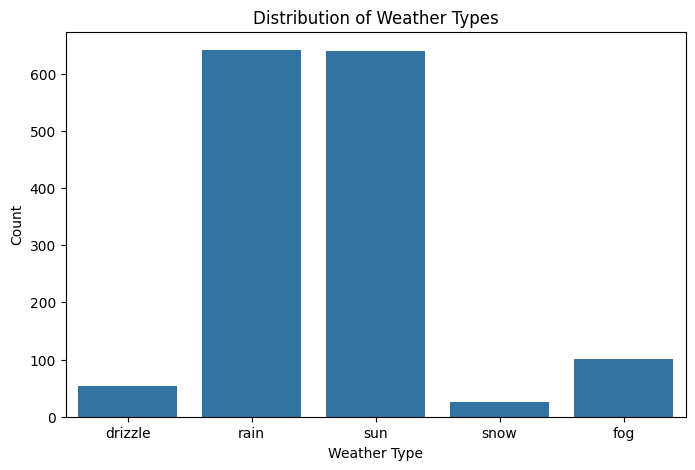

In [17]:
# Distribution of weather types
plt.figure(figsize=(8,5))
sns.countplot(x="weather", data=df)

plt.title("Distribution of Weather Types")
plt.xlabel("Weather Type")
plt.ylabel("Count")

plt.show()

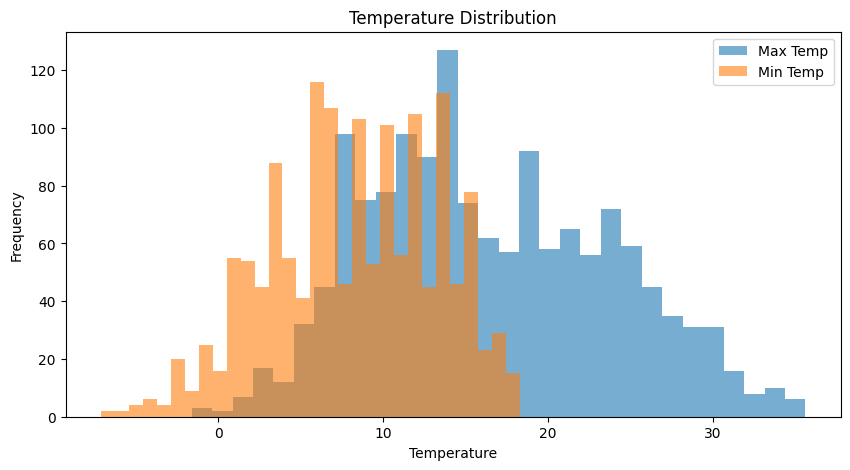

In [18]:
# Temperature distributions
plt.figure(figsize=(10,5))

plt.hist(df["temp_max"], bins=30, alpha=0.6, label="Max Temp")
plt.hist(df["temp_min"], bins=30, alpha=0.6, label="Min Temp")

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.legend()
plt.show()

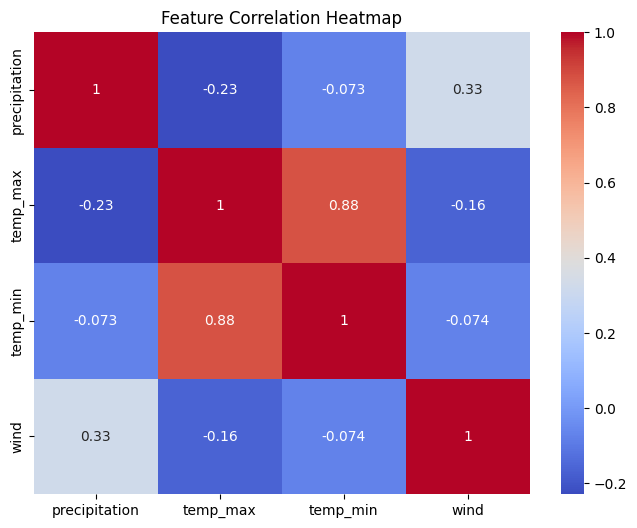

In [19]:
# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['precipitation','temp_max','temp_min','wind']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

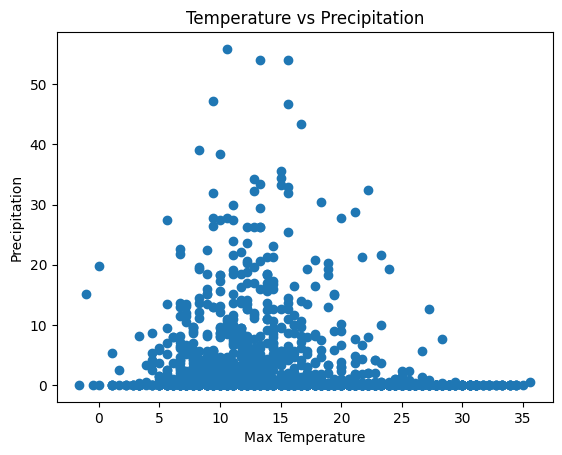

In [20]:
# Scatter plot
plt.scatter(df["temp_max"], df["precipitation"])

plt.xlabel("Max Temperature")
plt.ylabel("Precipitation")

plt.title("Temperature vs Precipitation")

plt.show()

##  Data Preprocessing

Data preprocessing is a critical step in preparing the dataset for machine learning models. Raw data often contains inconsistencies, varying scales, or categorical values that need transformation. Proper preprocessing ensures that the models can learn effectively and generalize well.

### Why Preprocessing is Needed
- **Machine learning models require numerical input.** Categorical values like "sun" or "rain" must be converted into numbers.  
- **Features with different ranges can bias models.** For example, precipitation values may range up to 50 mm, while wind speed is usually below 10 m/s. Without scaling, precipitation would dominate the model.  
- **Splitting the dataset into training and testing sets** ensures that we can evaluate the model on unseen data, preventing overfitting.  

Before building models, the dataset must be prepared.

Steps performed:

- Encoding categorical labels
- Creating regression and classification targets
- Splitting dataset into training and testing sets
- Feature scaling using standardization

The dataset is split into **80% training data and 20% testing data**.

In [21]:
# Encoding
# Convert weather into binary classification
# 1 = rain
# 0 = no rain

df["rain"] = (df["weather"] == "rain").astype(int)

df.head()

# Train-test split
X = df[['precipitation','temp_max','temp_min','wind']].values
y = df['rain'].values

# shuffle dataset
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Scaling
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

##  Model Building
We will build two models:  

## Linear Regression Model

Linear regression predicts continuous numerical values.

In this project:

- Linear regression predicts **precipitation**
- Temperature and wind are used as predictors

The model is implemented **manually using the Normal Equation**. 

## Logistic Regression Model

Logistic regression is used for classification problems.

In this project:

- The model predicts **rain vs no rain**
- Features used:
  - precipitation
  - temp_max
  - temp_min
  - wind

The model is implemented manually using **gradient descent optimization**.

In [22]:
X_lr = df[['temp_max','temp_min','wind']].values
y_lr = df['precipitation'].values

split = int(0.8 * len(X_lr))

X_train_lr = X_lr[:split]
X_test_lr = X_lr[split:]

y_train_lr = y_lr[:split]
y_test_lr = y_lr[split:]

# add bias column
X_train_lr = np.c_[np.ones(X_train_lr.shape[0]), X_train_lr]
X_test_lr = np.c_[np.ones(X_test_lr.shape[0]), X_test_lr]

# normal equation
theta = np.linalg.inv(X_train_lr.T.dot(X_train_lr)).dot(X_train_lr.T).dot(y_train_lr)

y_pred_lr = X_test_lr.dot(theta)

In [23]:
# Logistic Regression
def sigmoid(z):
    return 1/(1+np.exp(-z))

weights = np.zeros(X_train.shape[1])
bias = 0

lr = 0.01
epochs = 1000

for i in range(epochs):

    linear = np.dot(X_train, weights) + bias
    y_pred = sigmoid(linear)

    dw = (1/len(X_train)) * np.dot(X_train.T,(y_pred-y_train))
    db = (1/len(X_train)) * np.sum(y_pred-y_train)

    weights -= lr * dw
    bias -= lr * db

In [24]:
# Prediction function
def predict(X):

    linear = np.dot(X, weights) + bias
    y_pred = sigmoid(linear)

    return np.array([1 if i>0.5 else 0 for i in y_pred])

y_pred_clf = predict(X_test)

## Model Evaluation

Model performance is evaluated using standard metrics.

### Linear Regression Metrics

- **R² Score**
- **Mean Squared Error (MSE)**

### Logistic Regression Metrics

- **Accuracy**
- **Confusion Matrix**

R² Score: 0.2304207331655812
MSE: 48.804277727572256


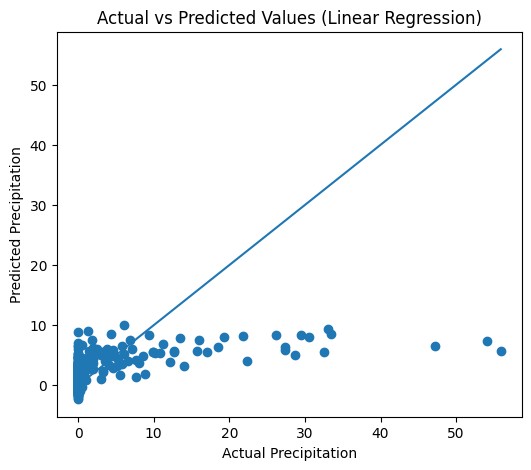

In [25]:
# Linear Regression Evaluation
mse = np.mean((y_test_lr - y_pred_lr)**2)

ss_total = np.sum((y_test_lr - np.mean(y_test_lr))**2)
ss_residual = np.sum((y_test_lr - y_pred_lr)**2)

r2 = 1 - (ss_residual/ss_total)

print("R² Score:", r2)
print("MSE:", mse)
# Plot predicted vs actual
plt.figure(figsize=(6,5))

plt.scatter(y_test_lr, y_pred_lr)

plt.plot(
    [y_test_lr.min(), y_test_lr.max()],
    [y_test_lr.min(), y_test_lr.max()]
)

plt.xlabel("Actual Precipitation")
plt.ylabel("Predicted Precipitation")

plt.title("Actual vs Predicted Values (Linear Regression)")

plt.show()

Accuracy: 0.764505119453925

Confusion matrix:
 [[137  19]
 [ 50  87]]


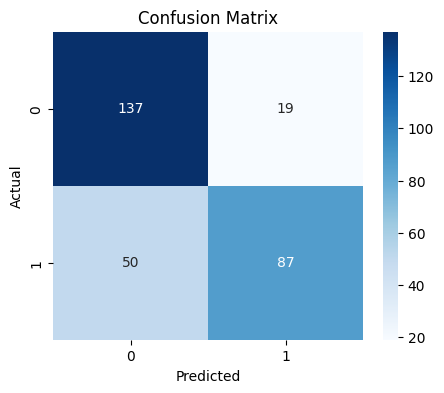

In [26]:
# Logistic Regression Evaluation
accuracy = np.mean(y_pred_clf == y_test)

print("Accuracy:", accuracy)

tp = tn = fp = fn = 0

for i in range(len(y_test)):

    if y_test[i]==1 and y_pred_clf[i]==1:
        tp+=1
    elif y_test[i]==0 and y_pred_clf[i]==0:
        tn+=1
    elif y_test[i]==0 and y_pred_clf[i]==1:
        fp+=1
    else:
        fn+=1

cm = np.array([[tn, fp],
               [fn, tp]])
print("\nConfusion matrix:\n",cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues") # Confusion matrix heatmap

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Interpretation of Results

The results obtained from both regression and classification models provide useful insights into the weather dataset.

### Linear Regression Interpretation

Linear regression was used to predict **precipitation values** using temperature and wind features.

* The **R² score** indicates how well the model explains the variation in precipitation values.
* The **Mean Squared Error (MSE)** measures the average squared difference between the actual and predicted precipitation values.
* The **Actual vs Predicted scatter plot** helps visualize model performance.

From the scatter plot:

* Points close to the diagonal line indicate **accurate predictions**.
* Points farther from the line represent **prediction errors**.

Overall, the regression model shows that temperature and wind have a noticeable relationship with precipitation, although precipitation can also depend on additional atmospheric factors not present in the dataset.

### Logistic Regression Interpretation

Logistic regression was used to classify whether rain occurs or not.

Model performance was evaluated using:

* **Accuracy** – measures the proportion of correct predictions.
* **Confusion Matrix** – shows how many predictions were correct or incorrect.

From the confusion matrix:

* **True Positives (TP):** correctly predicted rainy days.
* **True Negatives (TN):** correctly predicted non-rainy days.
* **False Positives (FP):** predicted rain when there was none.
* **False Negatives (FN):** failed to predict rain.

A higher number of correct predictions indicates that the model is able to identify rain patterns based on the weather features.


## Conclusion

This project analyzed a weather dataset and applied machine learning techniques to understand and predict weather patterns.

Main outcomes of the project include:

* Exploratory Data Analysis helped identify relationships between temperature, wind, and precipitation.
* **Linear Regression** was successfully implemented to estimate precipitation values.
* **Logistic Regression** was used to classify rain vs no rain conditions.
* Model evaluation using metrics such as **R² score, Mean Squared Error, Accuracy, and Confusion Matrix** helped assess the performance of the models.

Key observations:

* Temperature and wind features contribute to predicting precipitation trends.
* Logistic regression can reasonably classify rainy and non-rainy conditions based on available features.
* Visualizations such as scatter plots and heatmaps help in better understanding the model results.

**In conclusion, the project demonstrates how basic machine learning models and data analysis techniques can be applied to real-world weather data to generate meaningful insights and predictions.**
